Распределение типов событий:
event_type
EXPLOIT                 44
MALWARE-CNC             23
NETBIOS                 22
INDICATOR-COMPROMISE    11
Name: count, dtype: int64

Общее количество событий: 100


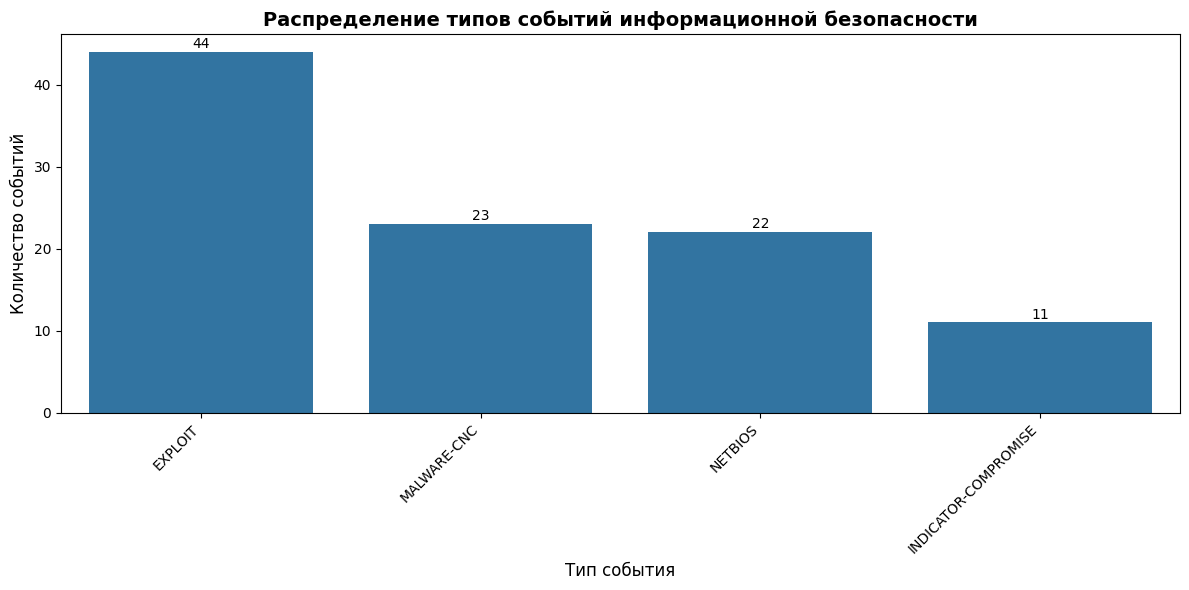


Статистика по времени:
Период: с 2023-08-21 08:00:00 по 2023-08-25 11:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

with open('events (1).json', 'r') as file:
    data = json.load(file)

df = pd.DataFrame(data["events"])

df['event_type'] = df['signature'].apply(lambda x: x.split()[0])

print("Распределение типов событий:")
print(df['event_type'].value_counts())
print("\nОбщее количество событий:", len(df))

plt.figure(figsize=(12, 6))

# График распределения
sns.countplot(data=df, x='event_type', order=df['event_type'].value_counts().index)
plt.title('Распределение типов событий информационной безопасности', fontsize=14, fontweight='bold')
plt.xlabel('Тип события', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Добавление подписей с количеством над столбцами
for i, count in enumerate(df['event_type'].value_counts().values):
    plt.text(i, count + 0.1, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nСтатистика по времени:")
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f"Период: с {df['timestamp'].min()} по {df['timestamp'].max()}")